# Bank Customer Churn
## Evidence before explanations

A reproducible exploratory study of 28,382 customer records. The report separates **churn rates**, **uncertainty**, and **association strength**. It describes this dataset; it does not establish causes or forecast future customers.

**Read in order:** data audit → customer segments → eleven association tests → missingness → financial behaviour → conclusions. All figures and tables below are computed from the committed CSV. No frontend or dashboard application is required.

## 1 · Setup and reproducibility
Run all cells in order. The setup cell installs the analysis dependencies only in Google Colab. Locally, install `requirements.txt` first. The CSV loads locally or from the public repository. Recency uses a fixed **31 December 2019** reference date, not today's date.

In [1]:
import sys, subprocess, importlib.util
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False
if IN_COLAB:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "pandas>=2.2,<4", "numpy>=2,<3", "scipy>=1.15,<2", "matplotlib>=3.9,<4"])
from pathlib import Path
import hashlib, json, platform
import numpy as np
import pandas as pd
import scipy
from scipy.stats import chi2_contingency, MonteCarloMethod, false_discovery_control
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from IPython.display import display, Markdown

SEED = 2026
REFERENCE_DATE = pd.Timestamp("2019-12-31")
OUT = Path("reports")
OUT.mkdir(exist_ok=True)
plt.rcParams.update({"figure.facecolor":"#F7F8FA", "axes.facecolor":"#F7F8FA", "axes.spines.top":False, "axes.spines.right":False, "axes.edgecolor":"#D3D8E0", "text.color":"#202C40", "axes.labelcolor":"#526179", "xtick.color":"#526179", "ytick.color":"#526179", "font.family":"DejaVu Sans", "font.size":10, "axes.titleweight":"bold", "axes.titlepad":18, "savefig.facecolor":"#F7F8FA", "figure.dpi":110})
BLUE, RED, MUTED = "#356AC3", "#B95268", "#526179"
def save_figure(fig, name):
    fig.savefig(OUT / f"{name}.png", dpi=160, bbox_inches="tight")
    plt.show()
    plt.close(fig)

def wilson(k, n):
    """Two-sided 95% Wilson score interval for a binomial proportion."""
    k, n = np.asarray(k, dtype=float), np.asarray(n, dtype=float)
    z = 1.959963984540054
    p = k / n
    denominator = 1 + z*z/n
    centre = (p + z*z/(2*n)) / denominator
    radius = z * np.sqrt(p*(1-p)/n + z*z/(4*n*n)) / denominator
    return np.maximum(0, centre-radius), np.minimum(1, centre+radius)

path = Path("churn_analysis.csv")
if not path.exists():
    from urllib.request import urlopen
    path.write_bytes(urlopen("https://raw.githubusercontent.com/harsh-github007/Analysis_Churn/main/churn_analysis.csv").read())
data_hash = hashlib.sha256(path.read_bytes()).hexdigest()
raw = pd.read_csv(path, na_values={"last_transaction": ["NaT"]})
df = raw.copy(deep=True)
print(f"Python {platform.python_version()} | pandas {pd.__version__} | SciPy {scipy.__version__}")
print(f"Dataset SHA256: {data_hash}")

Python 3.14.7 | pandas 3.0.6 | SciPy 1.18.1
Dataset SHA256: 54529b90d6095130639c5e30e7daa5ae005e6c66e846a7db7d67e69c9551afcf


## 2 · Data audit
Keep missing values and legitimate extremes visible. Customer, city and branch codes are identifiers, not continuous measurements. A negative balance is flagged for interpretation, not silently deleted. The dataset's original source, churn event definition and feature timing are not documented in the repository; these limits matter before modelling.

In [2]:
required = {"customer_id", "churn", "age", "last_transaction", "gender", "dependents", "occupation", "city", "branch_code", "customer_nw_category"}
assert required.issubset(df.columns)
assert df["customer_id"].notna().all() and df["customer_id"].is_unique
assert df["churn"].notna().all() and set(df["churn"].unique()) == {0,1}
assert len(df) == 28382 and len(df.columns) == 21
assert df["age"].between(0,120).all()
assert (df["dependents"].dropna() >= 0).all()
assert (df["dependents"].dropna() % 1 == 0).all()
dates = pd.to_datetime(df["last_transaction"], format="%Y-%m-%d", errors="coerce")
assert not (df["last_transaction"].notna() & dates.isna()).any()
assert dates.max() <= REFERENCE_DATE
df["days_since_transaction"] = (REFERENCE_DATE - dates).dt.days
missing = raw.isna().sum().sort_values(ascending=False)
audit = pd.DataFrame({"missing_records":missing, "missing_percent":100*missing/len(df)})
audit.to_csv(OUT / "data_quality.csv", index_label="feature")
display(audit.loc[audit.missing_records > 0].round(2))
print(f"{len(df):,} rows | {df.shape[1]-1} original columns | duplicate IDs: 0 | duplicate rows: {raw.duplicated().sum()}")
print(f"Recorded last transactions: {dates.min().date()} to {dates.max().date()}")
print(f"Negative current balances: {(df.current_balance < 0).sum():,}")
print(f"Rows with any missing field: {raw.isna().any(axis=1).sum():,}")

,missing_records,missing_percent
last_transaction,3223,11.36
dependents,2463,8.68
city,803,2.83
gender,525,1.85
occupation,80,0.28


28,382 rows | 21 original columns | duplicate IDs: 0 | duplicate rows: 0
Recorded last transactions: 2018-12-31 to 2019-12-31
Negative current balances: 17
Rows with any missing field: 6,315


## 3 · Churn in context
Report both the numerator and denominator. The interval quantifies sampling uncertainty under a binomial model; it does not fix unknown sampling design, label errors or temporal ambiguity.

**5,260 of 28,382 customers churned — 18.53%.**

95% Wilson interval: **18.09%–18.99%**. 23,122 customers have churn = 0.

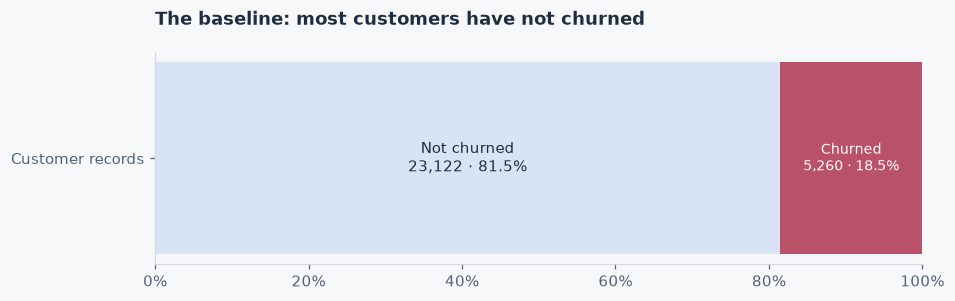

In [3]:
n = len(df)
k = int(df.churn.sum())
baseline = k/n
low, high = wilson(k,n)
display(Markdown(f"**{k:,} of {n:,} customers churned — {baseline:.2%}.**\n\n95% Wilson interval: **{low:.2%}–{high:.2%}**. {n-k:,} customers have churn = 0."))
fig, ax = plt.subplots(figsize=(9,2.5))
ax.barh(["Customer records"], [1-baseline], color="#D8E3F6", height=.38)
ax.barh(["Customer records"], [baseline], left=[1-baseline], color=RED, height=.38)
ax.text((1-baseline)/2,0,f"Not churned\n{n-k:,} · {1-baseline:.1%}",ha="center",va="center")
ax.text(1-baseline/2,0,f"Churned\n{k:,} · {baseline:.1%}",ha="center",va="center",color="white",fontsize=9)
ax.set_xlim(0,1); ax.xaxis.set_major_formatter(PercentFormatter(1));ax.set_title("The baseline: most customers have not churned",loc="left")
save_figure(fig,"01-churn-baseline")

## 4 · Segment rates and uncertainty
Points show observed churn rates; lines show individual **95% Wilson intervals**. Labels include customer counts. Small groups have visibly wider uncertainty. “Missing” remains a separate descriptive category. Age bands and the 182-day inactivity boundary are analysis choices, not externally validated business rules. Dependents are not a measurement of household size.

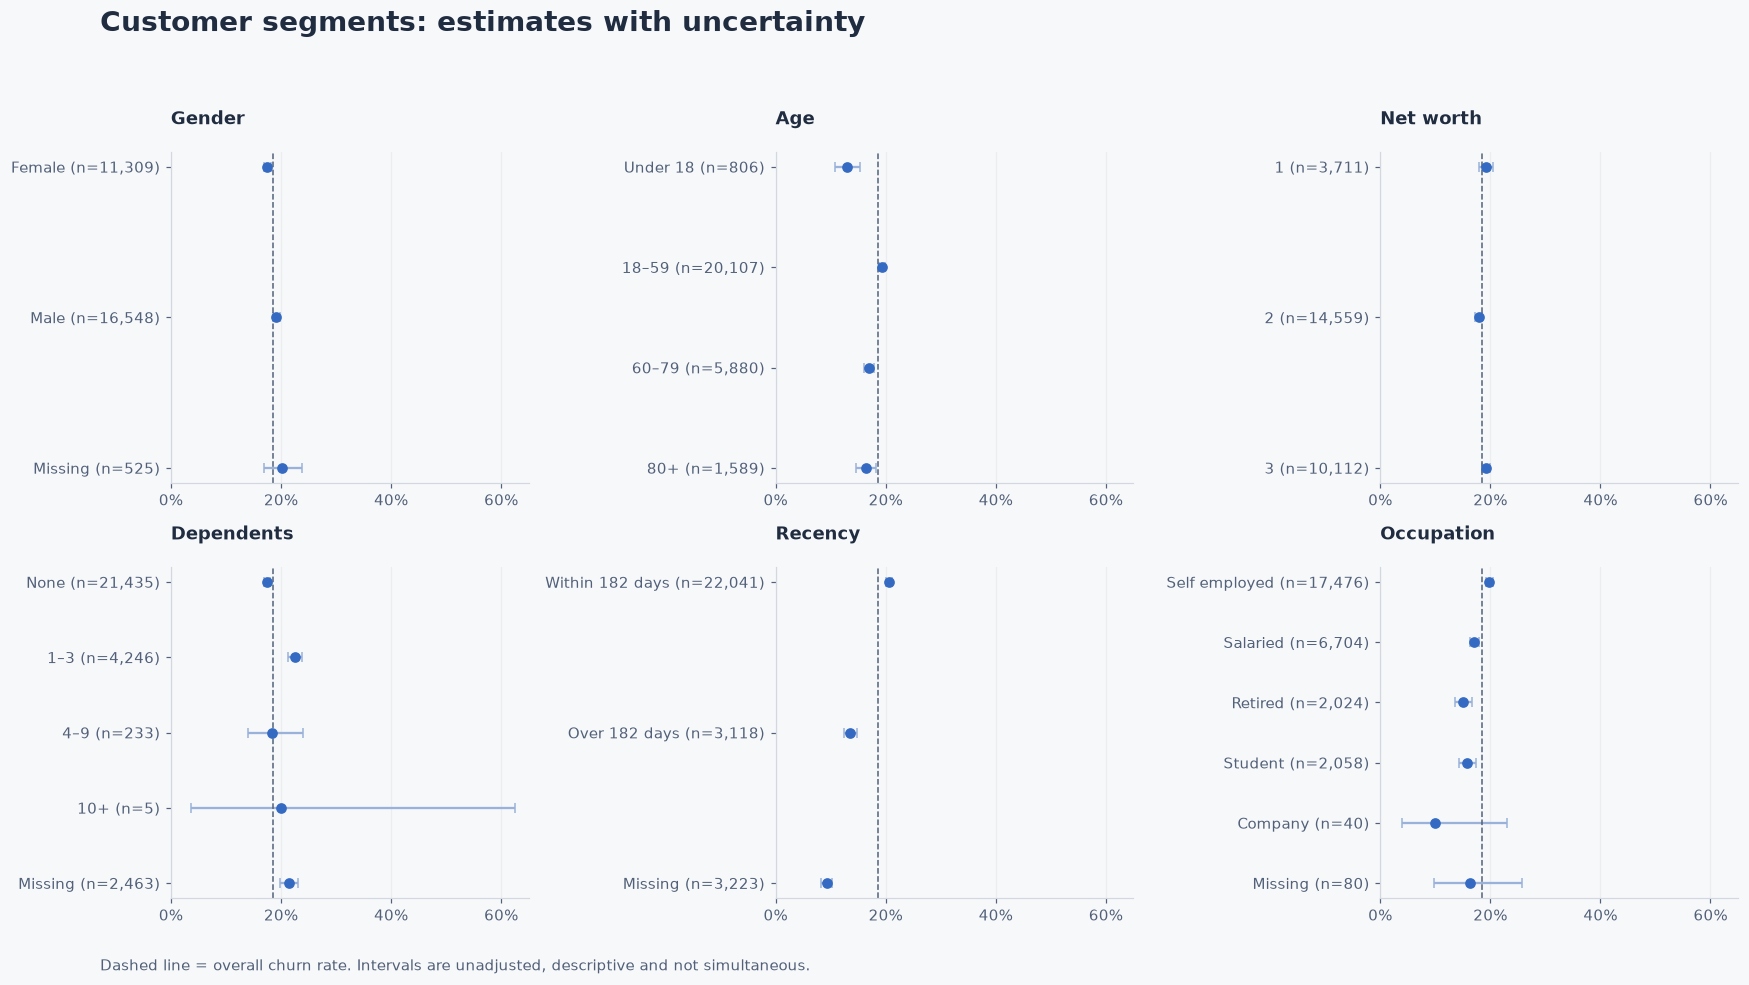

,group,churned,customers,rate,lower_95,upper_95,segment
0,Female,1985,11309,0.1755,0.1686,0.1826,Gender
1,Male,3169,16548,0.1915,0.1856,0.1976,Gender
2,Missing,106,525,0.2019,0.1698,0.2384,Gender
3,Under 18,104,806,0.1290,0.1076,0.1539,Age
4,18–59,3899,20107,0.1939,0.1885,0.1994,Age
5,60–79,996,5880,0.1694,0.1600,0.1792,Age
6,80+,261,1589,0.1643,0.1469,0.1833,Age
7,1,710,3711,0.1913,0.1790,0.2043,Net worth
8,2,2606,14559,0.1790,0.1729,0.1853,Net worth
9,3,1944,10112,0.1922,0.1847,0.2000,Net worth


In [4]:
def with_missing(series):
    return series.astype("string").fillna("Missing")
segments = {}
segments["Gender"] = with_missing(df.gender)
segments["Age"] = pd.cut(df.age, [-1,17,59,79,120], labels=["Under 18","18–59","60–79","80+"]).astype("string")
segments["Net worth"] = with_missing(df.customer_nw_category)
segments["Dependents"] = pd.cut(df.dependents, [-1,0,3,9,np.inf], labels=["None","1–3","4–9","10+"]).astype("string").fillna("Missing")
segments["Recency"] = pd.Series(np.where(df.days_since_transaction > 182,"Over 182 days","Within 182 days"), index=df.index).mask(df.days_since_transaction.isna(),"Missing")
segments["Occupation"] = with_missing(df.occupation)

def segment_rates(group):
    out = pd.DataFrame({"group":group, "churn":df.churn}).groupby("group", observed=True, sort=False).churn.agg(["sum","size"])
    out.columns = ["churned","customers"]
    out["rate"] = out.churned/out.customers
    out["lower_95"], out["upper_95"] = wilson(out.churned,out.customers)
    return out
orders={"Gender":["Female","Male","Missing"],"Age":["Under 18","18–59","60–79","80+"],"Net worth":["1","2","3"],"Dependents":["None","1–3","4–9","10+","Missing"],"Recency":["Within 182 days","Over 182 days","Missing"],"Occupation":["self_employed","salaried","retired","student","company","Missing"]}
all_rates=[]
fig, axes = plt.subplots(2,3,figsize=(16,9))
for ax, (name, group) in zip(axes.flat,segments.items()):
    rates=segment_rates(group).reindex(orders[name])
    all_rates.append(rates.reset_index().assign(segment=name))
    y=np.arange(len(rates))
    ax.errorbar(rates.rate,y,xerr=[rates.rate-rates.lower_95,rates.upper_95-rates.rate],fmt="o",color=BLUE,ecolor="#9AB2D9",capsize=3)
    ax.set_yticks(y,[f"{str(label).replace('_', ' ').capitalize()} (n={int(row.customers):,})" for label,row in rates.iterrows()])
    ax.invert_yaxis();ax.axvline(baseline,color=MUTED,ls="--",lw=1)
    ax.set_xlim(0,.65);ax.set_xticks([0,.2,.4,.6]);ax.xaxis.set_major_formatter(PercentFormatter(1));ax.set_title(name,loc="left");ax.grid(axis="x",alpha=.15)
fig.suptitle("Customer segments: estimates with uncertainty",x=.06,ha="left",fontsize=18,fontweight="bold")
fig.text(.06,.01,"Dashed line = overall churn rate. Intervals are unadjusted, descriptive and not simultaneous.",color=MUTED)
fig.tight_layout(rect=[0,.04,1,.94]);save_figure(fig,"02-segment-rates")
rates_table=pd.concat(all_rates,ignore_index=True)
rates_table.to_csv(OUT/"segment_rates.csv",index=False)
display(rates_table.round(4))

## 5 · Eleven association checks
The original eleven questions are retained as eleven clearly defined tests. The dependents-presence and dependents-band tests overlap; they do not provide independent confirmation. City and branch “size” means **number of customers in this sample**, not population or real branch capacity. Thresholds are computed from the sample size (1% and 0.5%).

Use uncorrected Pearson χ² for a consistent Cramér's V calculation. When any expected cell count is below five, estimate the p-value from **9,999 Monte Carlo tables with fixed margins**, using a fixed seed. Report both ordinary and bias-corrected Cramér's V. Apply **Benjamini–Yekutieli adjustment across all eleven tests** because the tests share customers and may be dependent. These are exploratory associations, not causal effects. Missing categories are excluded from substantive tests and assessed separately.

,test,customers,excluded_missing,groups,min_expected,method,p_value,cramers_v,bias_corrected_v,q_by,q_below_005
0,Gender,27857,525,2,2092.34971,Pearson χ²,0.00074,0.02021,0.01930,0.00412,True
1,Age band,28382,0,4,149.37496,Pearson χ²,0.00000,0.03815,0.03674,0.00000,True
2,Net worth category,28382,0,3,687.75492,Pearson χ²,0.01872,0.01674,0.01449,0.07775,False
3,Dependents presence,25919,2463,2,818.81137,Pearson χ²,0.00000,0.04731,0.04690,0.00000,True
4,Dependents bands,25919,2463,4,0.91304,Monte Carlo χ²,0.00010,0.04828,0.04706,0.00083,True
5,Transaction recency,25159,3223,2,614.82563,Pearson χ²,0.00000,0.05816,0.05782,0.00000,True
6,City sample size,27579,803,2,2373.01860,Pearson χ²,0.00187,0.01872,0.01773,0.00889,True
7,Branch sample size,28382,0,2,53.18935,Pearson χ²,0.56067,0.00345,0.00000,1.00000,False
8,Missing gender,28382,0,2,97.29758,Pearson χ²,0.32383,0.00586,0.00000,1.00000,False
9,Missing dependents,28382,0,2,456.46466,Pearson χ²,0.00013,0.02272,0.02193,0.00086,True


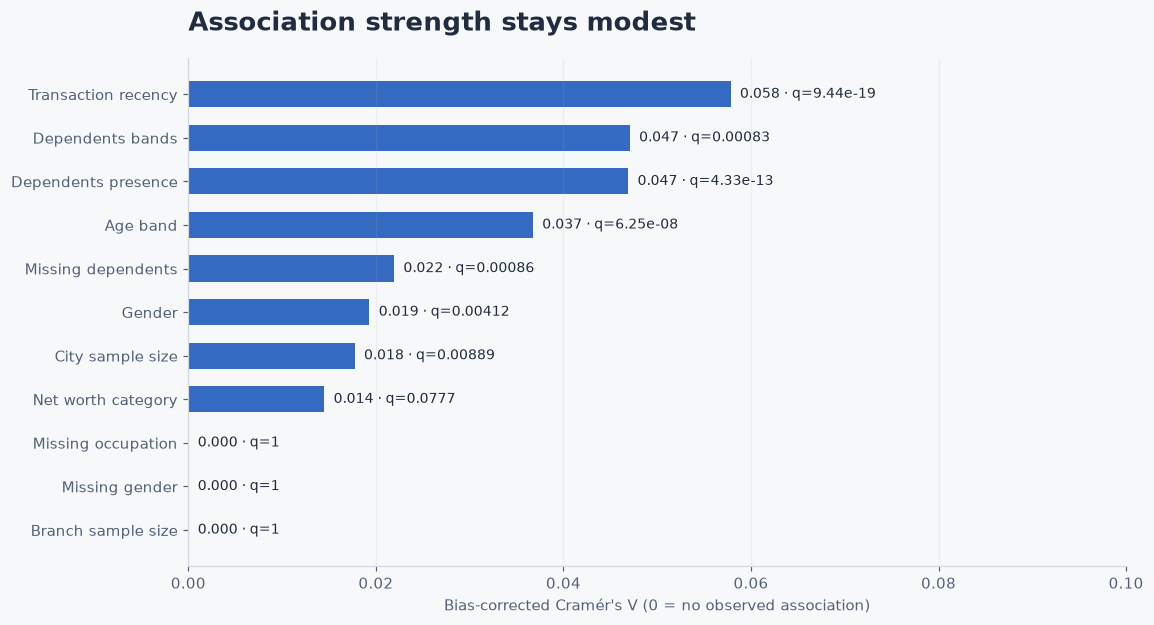

In [5]:
city_counts=df.city.value_counts()
branch_counts=df.branch_code.value_counts()
city_group=df.city.map(city_counts).map(lambda x: "Below 1% of sample" if x < .01*n else "At least 1% of sample" if pd.notna(x) else pd.NA)
# Keep unknown city unknown rather than assigning it to a size group.
city_group=city_group.mask(df.city.isna())
branch_group=df.branch_code.map(branch_counts).map(lambda x: "Below 0.5% of sample" if x < .005*n else "At least 0.5% of sample")
dep_presence=pd.Series(np.where(df.dependents > 0,"One or more","None"),index=df.index).mask(df.dependents.isna())
tests={
 "Gender":df.gender,
 "Age band":segments["Age"],
 "Net worth category":df.customer_nw_category,
 "Dependents presence":dep_presence,
 "Dependents bands":segments["Dependents"].mask(df.dependents.isna()),
 "Transaction recency":segments["Recency"].mask(dates.isna()),
 "City sample size":city_group,
 "Branch sample size":branch_group,
 "Missing gender":df.gender.isna().map({True:"Missing",False:"Recorded"}),
 "Missing dependents":df.dependents.isna().map({True:"Missing",False:"Recorded"}),
 "Missing occupation":df.occupation.isna().map({True:"Missing",False:"Recorded"}),
}

def association(name, group):
    table=pd.crosstab(group,df.churn).reindex(columns=[0,1],fill_value=0)
    table=table.loc[table.sum(axis=1)>0]
    assert min(table.shape)>1
    result=chi2_contingency(table.to_numpy(),correction=False)
    sparse=bool((result.expected_freq<5).any())
    p=float(result.pvalue)
    if sparse:
        p=float(chi2_contingency(table.to_numpy(),correction=False,method=MonteCarloMethod(n_resamples=9999,batch=100,rng=np.random.default_rng(SEED))).pvalue)
    total=int(table.to_numpy().sum());rows,cols=table.shape
    phi2=float(result.statistic)/total
    v=np.sqrt(phi2/min(rows-1,cols-1))
    phi_corrected=max(0,phi2-(rows-1)*(cols-1)/(total-1))
    denominator=min(rows-1-(rows-1)**2/(total-1),cols-1-(cols-1)**2/(total-1))
    v_corrected=np.sqrt(phi_corrected/denominator)
    return {"test":name,"customers":total,"excluded_missing":n-total,"groups":rows,"min_expected":float(result.expected_freq.min()),"method":"Monte Carlo χ²" if sparse else "Pearson χ²","p_value":p,"cramers_v":v,"bias_corrected_v":v_corrected}
results=pd.DataFrame([association(name,group) for name,group in tests.items()])
results["q_by"]=false_discovery_control(results.p_value.to_numpy(),method="by")
results["q_below_005"]=results.q_by < .05
results.to_csv(OUT/"hypothesis_tests.csv",index=False)
display(results.round(5))
fig,ax=plt.subplots(figsize=(11,6))
ranked=results.sort_values("bias_corrected_v")
ax.barh(ranked.test,ranked.bias_corrected_v,color=BLUE,height=.6)
ax.set_xlim(0,max(.1,ranked.bias_corrected_v.max()*1.3))
ax.set_xlabel("Bias-corrected Cramér's V (0 = no observed association)")
ax.set_title("Association strength stays modest",loc="left",fontsize=17)
for i,(_,row) in enumerate(ranked.iterrows()): ax.text(row.bias_corrected_v+.001,i,f"{row.bias_corrected_v:.3f} · q={row.q_by:.3g}",va="center",fontsize=9)
ax.grid(axis="x",alpha=.15);save_figure(fig,"03-association-strength")

### Sensitivity to arbitrary size cutoffs
If a branch or city conclusion depends on one cutoff, it is fragile. The following table varies those cutoffs; it is a descriptive sensitivity check, not another search for significant p-values.

In [6]:
sensitivity=[]
for field, thresholds in [("city",[.005,.01,.02]),("branch_code",[.0025,.005,.01])]:
    counts=df[field].value_counts()
    for threshold in thresholds:
        groups=df[field].map(counts).lt(threshold*n).map({True:"Below cutoff",False:"At/above cutoff"}).mask(df[field].isna())
        rates=segment_rates(groups).reset_index()
        rates["field"]=field;rates["sample_fraction_cutoff"]=threshold
        sensitivity.append(rates)
sensitivity_table=pd.concat(sensitivity,ignore_index=True)
sensitivity_table.to_csv(OUT/"size_cutoff_sensitivity.csv",index=False)
display(sensitivity_table[["field","sample_fraction_cutoff","group","customers","rate","lower_95","upper_95"]].round(4))

,field,sample_fraction_cutoff,group,customers,rate,lower_95,upper_95
0,city,0.0050,Below cutoff,10509,0.1961,0.1886,0.2038
1,city,0.0050,At/above cutoff,17070,0.1779,0.1722,0.1837
2,city,0.0100,Below cutoff,12840,0.1926,0.1859,0.1995
3,city,0.0100,At/above cutoff,14739,0.1780,0.1719,0.1843
4,city,0.0200,Below cutoff,14473,0.1910,0.1847,0.1975
5,city,0.0200,At/above cutoff,13106,0.1779,0.1715,0.1846
6,branch_code,0.0025,Below cutoff,25630,0.1870,0.1823,0.1918
7,branch_code,0.0025,At/above cutoff,2752,0.1697,0.1561,0.1842
8,branch_code,0.0050,Below cutoff,28095,0.1852,0.1807,0.1898
9,branch_code,0.0050,At/above cutoff,287,0.1986,0.1566,0.2486


## 6 · Missingness is part of the evidence
The chart separates absent information from recorded values. Do not replace unknown dependents with zero or infer a missing city without checking the branch-to-city mapping. Missingness associations can reflect data collection as well as customer behaviour.

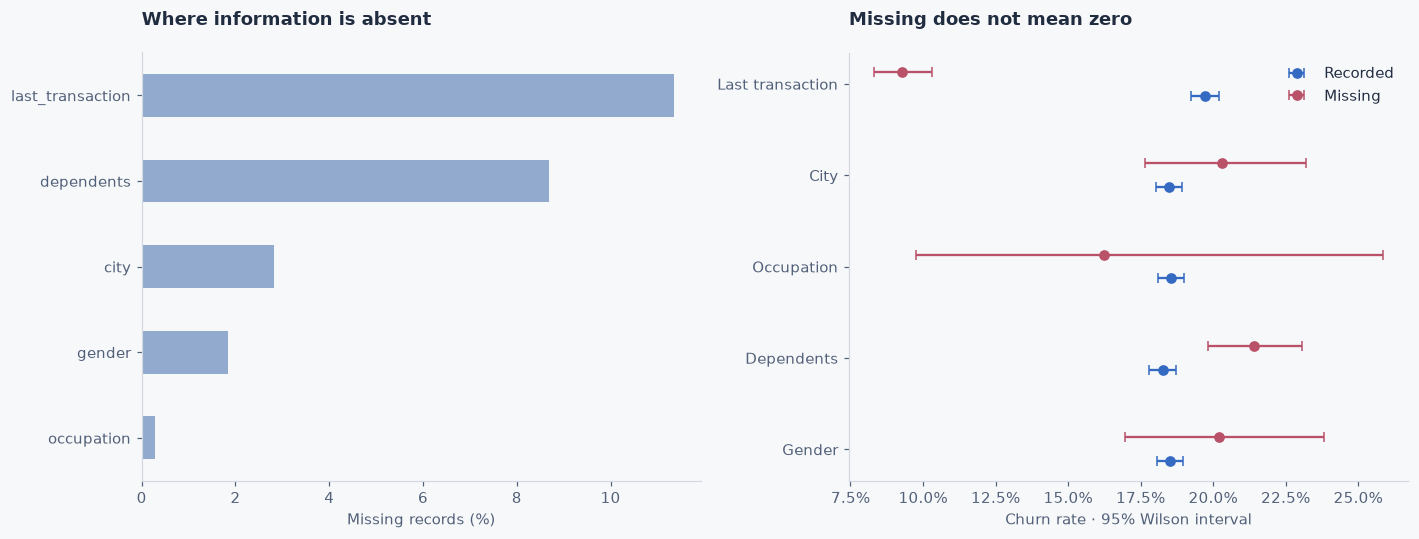

In [7]:
fig,axes=plt.subplots(1,2,figsize=(13,5))
audit.loc[audit.missing_records>0,"missing_percent"].sort_values().plot.barh(ax=axes[0],color="#92AACD")
axes[0].set_title("Where information is absent",loc="left");axes[0].set_xlabel("Missing records (%)")
missing_rates=[]
for field in ["gender","dependents","occupation","city","last_transaction"]:
    rates=segment_rates(df[field].isna().map({True:"Missing",False:"Recorded"}))
    missing_rates.append(rates.reset_index().assign(feature=field))
missing_table=pd.concat(missing_rates,ignore_index=True)
for status,color_,offset in [("Recorded",BLUE,-.13),("Missing",RED,.13)]:
    subset=missing_table[missing_table.group==status]
    axes[1].errorbar(subset.rate,np.arange(5)+offset,xerr=[subset.rate-subset.lower_95,subset.upper_95-subset.rate],fmt="o",color=color_,capsize=3,label=status)
axes[1].set_yticks(np.arange(5),["Gender","Dependents","Occupation","City","Last transaction"])
axes[1].set_title("Missing does not mean zero",loc="left");axes[1].xaxis.set_major_formatter(PercentFormatter(1));axes[1].set_xlabel("Churn rate · 95% Wilson interval");axes[1].legend(frameon=False)
fig.tight_layout();save_figure(fig,"04-missingness")
missing_table.to_csv(OUT/"missingness_rates.csv",index=False)

## 7 · Financial behaviour without deleting extremes
All records remain in the analysis. A **signed log1p transform** preserves zeros and negative balances while compressing the display scale. These transformed values are used only for plotting. Financial units are not documented, so no currency symbol is assumed. Correlations use original variables with pairwise available observations; the pair counts are exported alongside the coefficients.

The accompanying table reports medians and interquartile ranges by churn, plus changes in monthly average balance and credit minus debit. Those features may overlap the churn event; their differences must not be interpreted as prospective predictors.

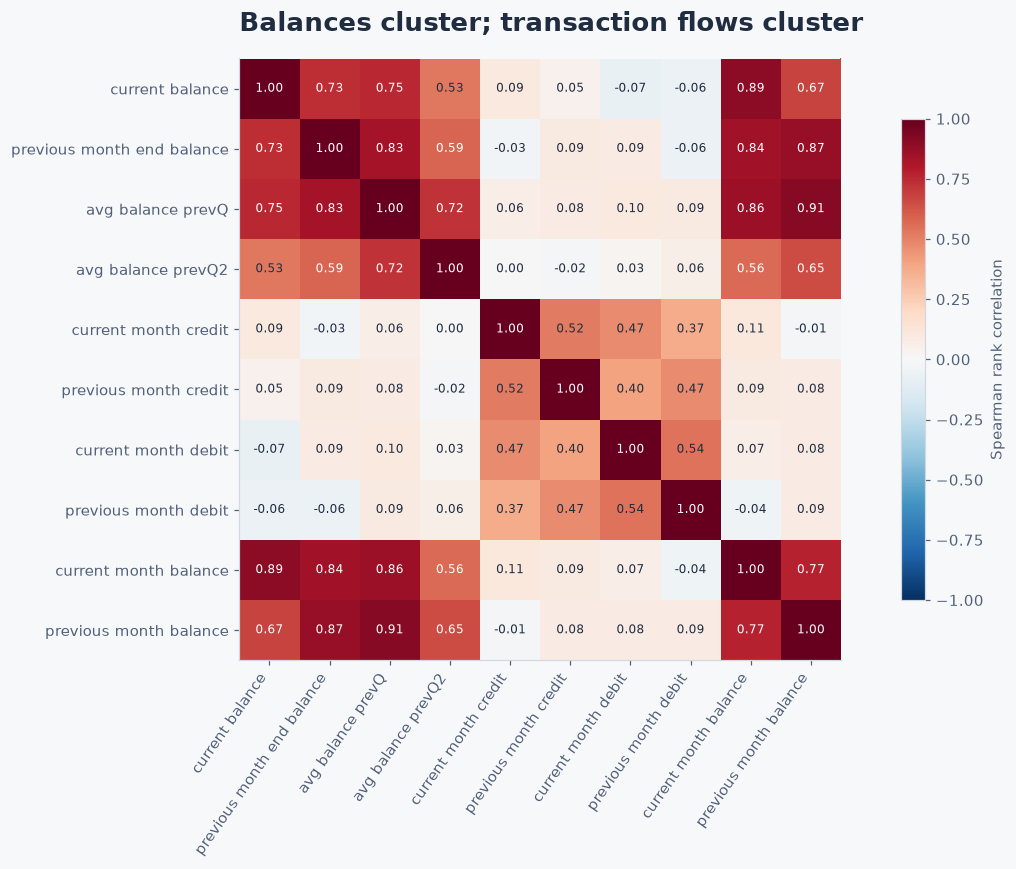

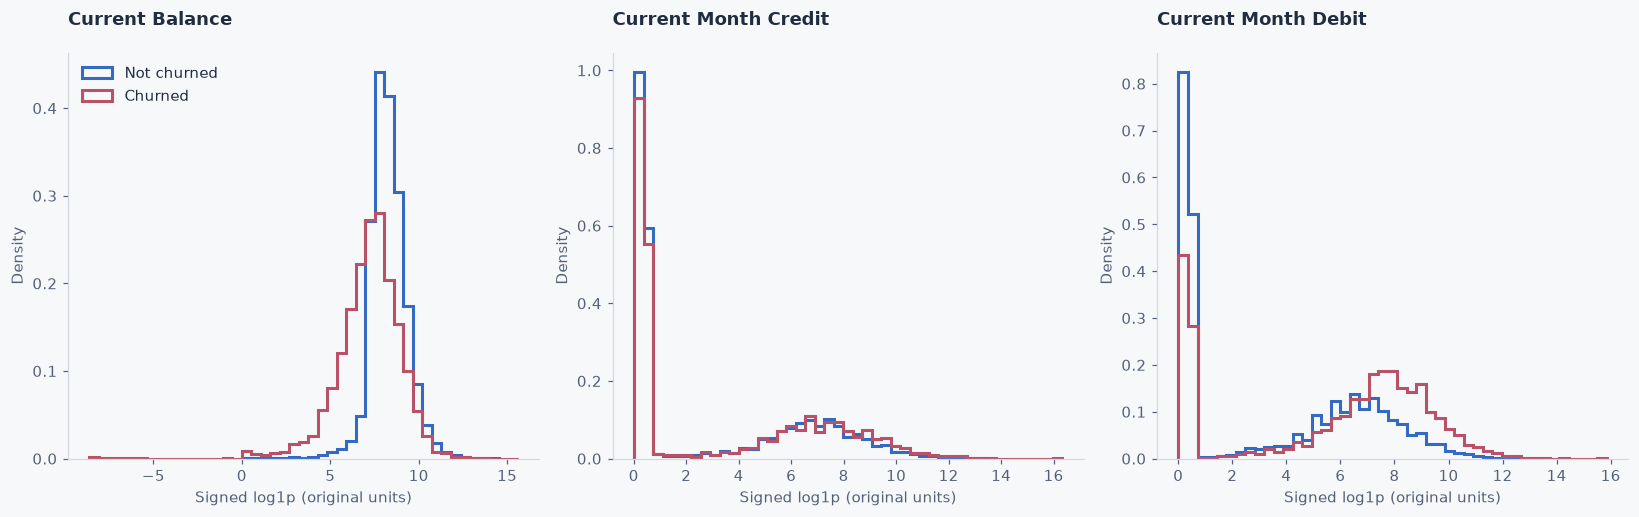

,count,50%,90%,99%,min,max
current_balance,28382.0,3281.26,13526.02,64781.36,-5503.96,5905904.03
previous_month_end_balance,28382.0,3379.92,13345.16,66212.91,-3149.57,5740438.63
average_monthly_balance_prevQ,28382.0,3542.86,13013.06,60118.23,1428.69,5700289.57
average_monthly_balance_prevQ2,28382.0,3359.60,12785.33,59357.88,-16506.10,5010170.10
current_month_credit,28382.0,0.61,4065.61,50047.00,0.01,12269845.39
previous_month_credit,28382.0,0.63,4385.48,51797.68,0.01,2361808.29
current_month_debit,28382.0,91.93,5500.56,51328.90,0.01,7637857.36
previous_month_debit,28382.0,109.96,5633.99,48353.83,0.01,1414168.06
current_month_balance,28382.0,3448.00,13155.64,64051.41,-3374.18,5778184.77
previous_month_balance,28382.0,3465.23,13132.53,62877.43,-5171.92,5720144.50


churn                                         0        1
current_balance                count   23122.00  5260.00
                               median   3643.12  1540.88
                               p25      2093.26   526.25
                               p75      7112.48  4004.15
previous_month_end_balance     count   23122.00  5260.00
                               median   3457.74  2928.58
                               p25      2015.67  1318.06
                               p75      6630.08  6839.78
average_monthly_balance_prevQ  count   23122.00  5260.00
                               median   3507.60  3721.28
                               p25      2175.70  2203.44
                               p75      6544.42  7261.02
average_monthly_balance_prevQ2 count   23122.00  5260.00
                               median   3383.36  3206.38
                               p25      1904.61  1377.11
                               p75      6410.72  7138.98
current_month_credit           count   23122.00  5260.00
                               median      0.61     0.66
                               p25         0.31     0.33
                               p75       643.48   958.84
previous_month_credit          count   23122.00  5260.00
                               median      0.61     2.50
                               p25         0.31     0.36
                               p75       671.74  1711.55
current_month_debit            count   23122.00  5260.00
                               median     21.98  1120.16
                               p25         0.37     0.70
                               p75       831.22  4571.45
previous_month_debit           count   23122.00  5260.00
                               median     42.94   837.46
                               p25         0.39     0.63
                               p75       900.26  4404.86
current_month_balance          count   23122.00  5260.00
                               median   3610.58  2554.11
                               p25      2167.43  1224.20
                               p75      6906.08  5718.54
previous_month_balance         count   23122.00  5260.00
                               median   3426.86  3696.01
                               p25      2079.08  2047.50
                               p75      6444.64  7610.88
monthly_average_balance_change count   23122.00  5260.00
                               median      0.00  -742.84
                               p25      -204.11 -2625.78
                               p75       355.54     0.00
current_month_net_flow         count   23122.00  5260.00
                               median      0.00  -357.15
                               p25      -257.15 -2628.52
                               p75        55.28     0.00

In [8]:
financial=["current_balance","previous_month_end_balance","average_monthly_balance_prevQ","average_monthly_balance_prevQ2","current_month_credit","previous_month_credit","current_month_debit","previous_month_debit","current_month_balance","previous_month_balance"]
summary=df[financial].describe(percentiles=[.1,.5,.9,.99]).T
summary.to_csv(OUT/"financial_summary.csv",index_label="feature")
spearman=df[financial].corr(method="spearman",min_periods=100)
spearman.to_csv(OUT/"spearman_correlations.csv",index_label="feature")
available=df[financial].notna().astype(int)
pair_counts=available.T @ available
pair_counts.to_csv(OUT/"correlation_pair_counts.csv",index_label="feature")
fig,ax=plt.subplots(figsize=(12,8))
im=ax.imshow(spearman,vmin=-1,vmax=1,cmap="RdBu_r")
labels=[s.replace("_"," ").replace("average monthly balance ","avg balance ") for s in financial]
ax.set_xticks(range(len(financial)),labels,rotation=55,ha="right");ax.set_yticks(range(len(financial)),labels)
for i in range(len(financial)):
    for j in range(len(financial)):
        ax.text(j,i,f"{spearman.iloc[i,j]:.2f}",ha="center",va="center",color="white" if abs(spearman.iloc[i,j])>.55 else "#202C40",fontsize=8)
fig.colorbar(im,ax=ax,shrink=.8,label="Spearman rank correlation")
ax.set_title("Balances cluster; transaction flows cluster",loc="left",fontsize=17)
fig.tight_layout();save_figure(fig,"05-financial-correlations")
fig,axes=plt.subplots(1,3,figsize=(15,4.8))
for ax,field in zip(axes,["current_balance","current_month_credit","current_month_debit"]):
    values=df[field]
    transformed=np.sign(values)*np.log1p(np.abs(values))
    edges=np.histogram_bin_edges(transformed.dropna(),bins=45)
    for label,color_ in [(0,BLUE),(1,RED)]:
        ax.hist(transformed[df.churn==label].dropna(),bins=edges,density=True,histtype="step",lw=2,color=color_,label="Churned" if label else "Not churned")
    ax.set_title(field.replace("_"," ").title(),loc="left");ax.set_xlabel("Signed log1p (original units)");ax.set_ylabel("Density")
axes[0].legend(frameon=False);fig.tight_layout();save_figure(fig,"06-financial-distributions")
display(summary[["count","50%","90%","99%","min","max"]].round(2))
# Descriptive financial comparisons retain all customers and original units.
comparison=df[financial+["churn"]].copy()
comparison["monthly_average_balance_change"]=df.current_month_balance-df.previous_month_balance
comparison["current_month_net_flow"]=df.current_month_credit-df.current_month_debit
financial_by_churn=comparison.groupby("churn").agg(["count","median",lambda x:x.quantile(.25),lambda x:x.quantile(.75)])
financial_by_churn.columns=pd.MultiIndex.from_tuples([(field,{"<lambda_0>":"p25","<lambda_1>":"p75"}.get(stat,stat)) for field,stat in financial_by_churn.columns])
financial_by_churn.to_csv(OUT/"financial_by_churn.csv")
display(financial_by_churn.T.round(2))


## 8 · Findings and next decisions
An association with the recorded churn flag cannot tell us whether a feature was measured before or after an account closed. In particular, recent activity must not be described as a cause of churn, and dormant accounts must not be assumed to be “protected”. Net worth categories are coded groups, not verified income brackets.

Potential segment priorities are **questions for follow-up**, not ready-to-use targeting rules. Check the label horizon and customer sampling; investigate data capture for missing fields; collect pre-churn longitudinal features; then evaluate a multivariate model using a genuine future-period holdout. Avoid using demographic differences alone for interventions.

In [9]:
recency_rates=segment_rates(segments["Recency"])
observed_max=results.cramers_v.max()
supported=results.loc[results.q_below_005,"test"].tolist()
display(Markdown(f"""### What the data supports
- **Churn baseline:** {baseline:.2%} ({k:,}/{n:,}).
- **Small one-variable associations:** maximum ordinary Cramér's V = {observed_max:.3f}; adjusted p-values do not make small effects large.
- **Recency pattern:** over 182 days = {recency_rates.loc['Over 182 days','rate']:.1%}; within 182 days = {recency_rates.loc['Within 182 days','rate']:.1%}; unknown date = {recency_rates.loc['Missing','rate']:.1%}. The mechanism is unknown.
- **{len(supported)} of eleven tests pass q < .05 after BY adjustment.** This is an exploratory family of tests on one sample.
- **Uncertainty matters:** tiny dependent groups and missing occupation have wide intervals; branch comparisons are sensitive to the sample-size grouping.
- **No predictive score is claimed.** Unknown label timing prevents an honest prospective validation claim.
"""))
manifest={"dataset_sha256":data_hash,"rows":n,"churned":k,"churn_rate":baseline,"reference_date":str(REFERENCE_DATE.date()),"random_seed":SEED,"monte_carlo_resamples":9999,"p_adjustment":"Benjamini–Yekutieli, eleven tests","versions":{"python":platform.python_version(),"pandas":pd.__version__,"numpy":np.__version__,"scipy":scipy.__version__,"matplotlib":matplotlib.__version__}}
(OUT/"run_manifest.json").write_text(json.dumps(manifest,indent=2)+"\n")
assert len(results)==11 and results.q_by.between(0,1).all()
assert rates_table.customers.groupby(rates_table.segment).sum().eq(n).all()
assert ((rates_table.lower_95<=rates_table.rate)&(rates_table.rate<=rates_table.upper_95)).all()
assert raw.equals(pd.read_csv(path, na_values={"last_transaction": ["NaT"]})), "The source dataset must remain unchanged."
print("Integrity checks passed: segment denominators, intervals, test family and unchanged source data.")

### What the data supports
- **Churn baseline:** 18.53% (5,260/28,382).
- **Small one-variable associations:** maximum ordinary Cramér's V = 0.058; adjusted p-values do not make small effects large.
- **Recency pattern:** over 182 days = 13.6%; within 182 days = 20.6%; unknown date = 9.3%. The mechanism is unknown.
- **7 of eleven tests pass q < .05 after BY adjustment.** This is an exploratory family of tests on one sample.
- **Uncertainty matters:** tiny dependent groups and missing occupation have wide intervals; branch comparisons are sensitive to the sample-size grouping.
- **No predictive score is claimed.** Unknown label timing prevents an honest prospective validation claim.


Integrity checks passed: segment denominators, intervals, test family and unchanged source data.


## Methods and references
- Wilson score intervals are descriptive, individual 95% intervals; no simultaneous interval coverage is claimed.
- Cramér's V uses Pearson χ² without continuity correction; the bias-corrected estimate adjusts for table size. Monte Carlo p-values use fixed-margin tables when expected counts are sparse.
- [SciPy contingency-table tests](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.contingency.chi2_contingency.html) explain expected-count assumptions and resampling.
- [SciPy false-discovery control](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.false_discovery_control.html) documents BY adjustment under dependence.
- [Bergsma (2013): bias correction for Cramér's V](https://doi.org/10.1016/j.jkss.2012.10.002).

**Limitations:** observational sample; undocumented original provenance and label definition; no event horizon; no sampling weights; static snapshot; overlapping tests; arbitrary exploratory cutoffs. Results describe the committed data and should not be generalized without validation.